# Appendix: Empirical Analysis - Monroe et al. (2022)

In [11]:
import os
from pathlib import Path
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, spearmanr


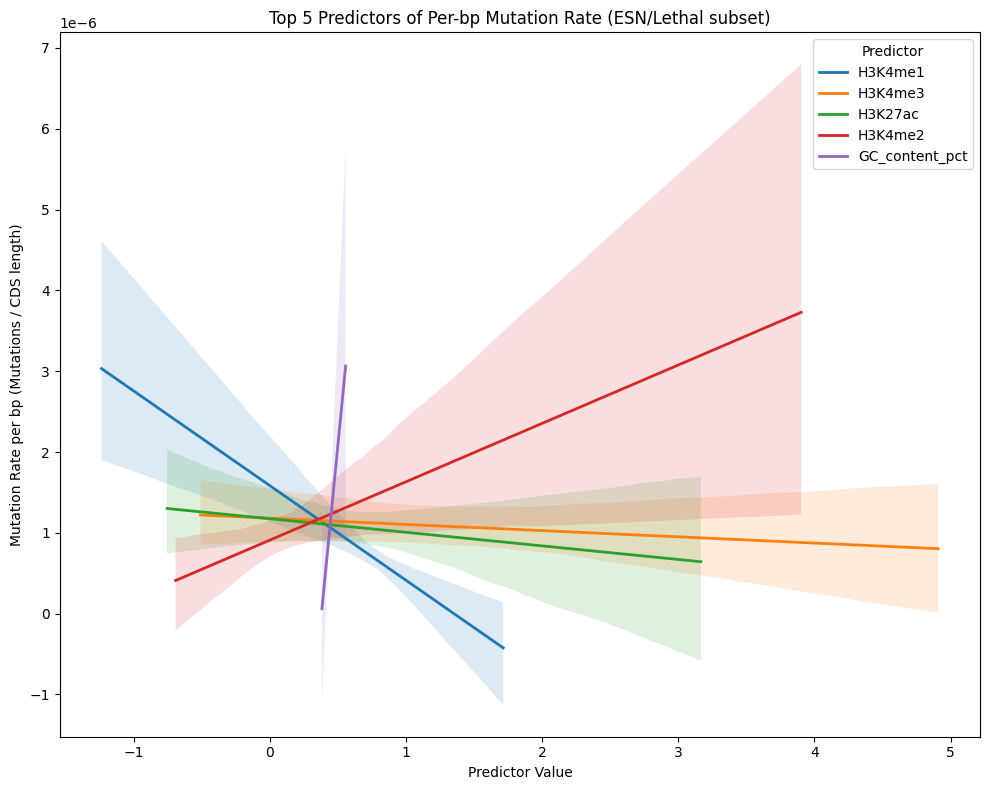

Top 5 significant predictors (p < 0.05):
       H3K4me1  p = 1.64e-08  beta = -2.781e-06
       H3K4me3  p = 2.74e-06  beta = -2.004e-06
       H3K27ac  p = 2.11e-04  beta = -1.926e-06
       H3K4me2  p = 2.42e-02  beta = 7.477e-07
  GC_content_pct  p = 4.15e-02  beta = 1.878e-05

GC_content_pct effect:
  beta = 1.878e-05
  p    = 4.15e-02
  95% CI = [7.279e-07, 3.683e-05]

Full model summary:
                            OLS Regression Results                            
Dep. Variable:        mut_rate_per_bp   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     5.850
Date:                Sat, 23 Aug 2025   Prob (F-statistic):           3.11e-13
Time:                        20:15:55   Log-Likelihood:                 7981.9
No. Observations:                 719   AIC:                        -1.593e+04
Df Residuals:                     700   BIC:      

In [ ]:
DATA_PATH = Path.home() / "Documents/GitHub/Random_Modifier/Data/gene_level_data.csv"
FIGURE_DIR = Path.cwd() / "Figures"
FIGURE_FILE = FIGURE_DIR / "af1_reg_lines_mutations.png"

# Predictor columns you expect
PREDICTORS = [
    "atac_pct", "GC_content_pct", "CHG_pct", "CHH_pct", "CG_pct",
    "H3K9me2", "H3K9me1", "H3K9ac", "H3K56ac",
    "H3K4me3", "H3K4me2", "H3K4me1",
    "H3K36me3", "H3K36ac",
    "H3K27me1", "H3K27ac", "H3K23ac", "H3K14ac",
]

# --- Load & Filter ---------------------------------------------------------

# 1. Load data
df = pd.read_csv(DATA_PATH)

# 2. Filter for ESN or lethal genes
df = df[(df["essentiality"] == "ESN") | (df["lethal"] == True)].copy()

# 3. Ensure predictors exist
missing = set(PREDICTORS) - set(df.columns)
if missing:
    raise ValueError(f"The following predictors are missing from the data: {missing}")

# 4. Drop rows with NaNs in any predictor or in 'Mutations' and 'CDS length'
df = df.dropna(subset=PREDICTORS + ["Mutations", "CDS length"]).copy()

# --- Regression ------------------------------------------------------------

# 5. Compute per-bp mutation rate (normalize by CDS length)
eps = 1e-9
df["mut_rate_per_bp"] = df["Mutations"] / (df["CDS length"] + eps)

# 6. Prepare X and y
X = df[PREDICTORS]
X = sm.add_constant(X)        # adds intercept
y = df["mut_rate_per_bp"]

# 7. Fit OLS model
model = sm.OLS(y, X).fit()

# 8. Identify top 5 significant predictors (p < 0.05), excluding the intercept
significant = model.pvalues.drop("const", errors="ignore").loc[lambda s: s < 0.05]
top5 = significant.sort_values().head(5).index.tolist()

# --- Plotting --------------------------------------------------------------

# 9. Ensure the Figures directory exists
FIGURE_DIR.mkdir(exist_ok=True, parents=True)

# 10. Plot regression lines for the top 5 predictors
plt.figure(figsize=(10, 8))
for predictor in top5:
    sns.regplot(
        x=df[predictor],
        y=df["mut_rate_per_bp"],
        label=predictor,
        scatter=False,
        line_kws={"linewidth": 2}
    )

plt.xlabel("Predictor Value")
plt.ylabel("Mutation Rate per bp (Mutations / CDS length)")
plt.title("Top 5 Predictors of Per-bp Mutation Rate (ESN/Lethal subset)")
plt.legend(title="Predictor")
plt.tight_layout()

# 11. Save the figure
plt.savefig(FIGURE_FILE, dpi=300)
plt.show()

# --- Reporting -------------------------------------------------------------

print("Top 5 significant predictors (p < 0.05):")
for pred, pval in significant.loc[top5].items():
    print(f"  {pred:>12s}  p = {pval:.2e}  beta = {model.params[pred]:.3e}")

print("\nGC_content_pct effect:")
if "GC_content_pct" in model.params:
    ci_low, ci_high = model.conf_int().loc["GC_content_pct"]
    print(f"  beta = {model.params['GC_content_pct']:.3e}")
    print(f"  p    = {model.pvalues['GC_content_pct']:.2e}")
    print(f"  95% CI = [{ci_low:.3e}, {ci_high:.3e}]")

print("\nFull model summary:")
print(model.summary())


In [ ]:
# Keep only valid, non-intercept predictors
top5 = [p for p in top5 if p in model.params.index and p != "const"]

# Confidence intervals for top5
ci = model.conf_int().loc[top5]

# Build numeric summary table
top5_summary_df = pd.DataFrame({
    "Predictor": top5,
    "Beta":      model.params.loc[top5].values,
    "SE":        model.bse.loc[top5].values,
    "t":         model.tvalues.loc[top5].values,
    "pval":      model.pvalues.loc[top5].values,
    "CI_low":    ci[0].values,
    "CI_high":   ci[1].values,
})

# Sort by numeric p-value
top5_summary_df = top5_summary_df.sort_values("pval").reset_index(drop=True)

# Pretty formatting for display (keep a copy so numeric types remain in top5_summary_df)
top5_display = top5_summary_df.copy()
top5_display["Beta"]   = top5_display["Beta"].map(lambda x: f"{x:.3e}")
top5_display["SE"]     = top5_display["SE"].map(lambda x: f"{x:.2e}")
top5_display["t"]      = top5_display["t"].map(lambda x: f"{x:.2f}")
top5_display["pval"]   = top5_display["pval"].map(lambda x: f"{x:.2e}")
top5_display["95% CI"] = top5_display.apply(
    lambda r: f"[{r['CI_low']:.2e}, {r['CI_high']:.2e}]",
    axis=1
)
top5_display = top5_display[["Predictor", "Beta", "SE", "t", "pval", "95% CI"]]

# Display (or print) the nicely formatted table
top5_display


,Predictor,Beta,SE,t,pval,95% CI
0,H3K4me1,-2.781e-06,4.87e-07,-5.71,1.64e-08,"[-3.74e-06, -1.83e-06]"
1,H3K4me3,-2.004e-06,4.24e-07,-4.73,2.74e-06,"[-2.84e-06, -1.17e-06]"
2,H3K27ac,-1.926e-06,5.17e-07,-3.72,2.11e-04,"[-2.94e-06, -9.11e-07]"
3,H3K4me2,7.477e-07,3.31e-07,2.26,2.42e-02,"[9.80e-08, 1.40e-06]"
4,GC_content_pct,1.878e-05,9.19e-06,2.04,4.15e-02,"[7.28e-07, 3.68e-05]"


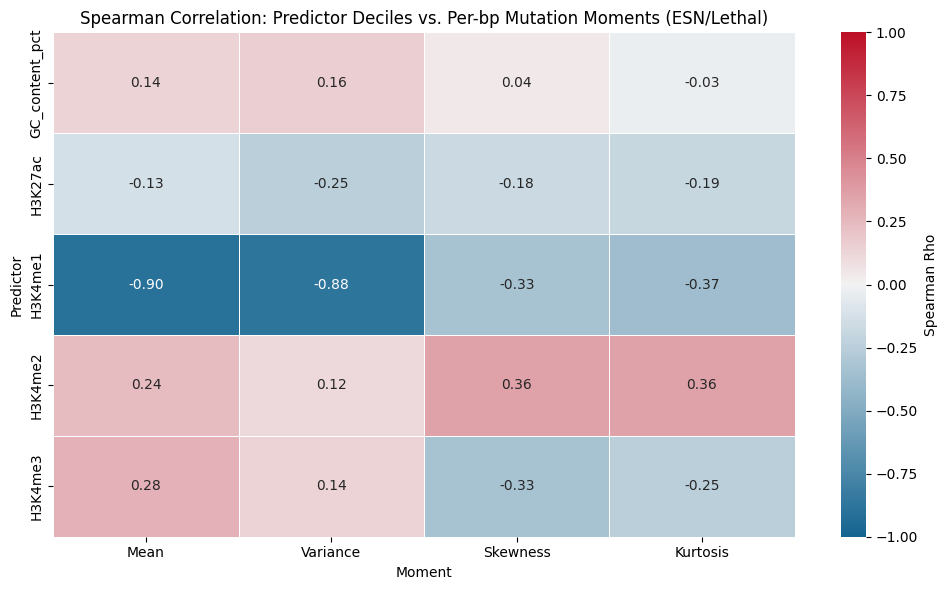

        Predictor          Beta            SE         t          pval  \
0         H3K4me1 -2.780940e-06  4.867188e-07 -5.713647  1.636013e-08   
1         H3K4me3 -2.003943e-06  4.238172e-07 -4.728321  2.738261e-06   
2         H3K27ac -1.926363e-06  5.171825e-07 -3.724725  2.112707e-04   
3         H3K4me2  7.476747e-07  3.309017e-07  2.259507  2.415852e-02   
4  GC_content_pct  1.878015e-05  9.194550e-06  2.042530  4.147311e-02   

         CI_low       CI_high  
0 -3.736543e-06 -1.825336e-06  
1 -2.836049e-06 -1.171838e-06  
2 -2.941777e-06 -9.109479e-07  
3  9.799609e-08  1.397353e-06  
4  7.279467e-07  3.683235e-05  


In [ ]:
# Paths
DATA_PATH = Path.home() / "Documents/GitHub/Random_Modifier/Data/gene_level_data.csv"
FIG_DIR   = Path.cwd() / "Figures"
FIG_DIR.mkdir(exist_ok=True, parents=True)
FIG_HEAT  = FIG_DIR / "af2_modifiers_mutations_m.png"

# Predictors
PREDICTORS = [
    "atac_pct", "GC_content_pct", "CHG_pct", "CHH_pct", "CG_pct",
    "H3K9me2", "H3K9me1", "H3K9ac", "H3K56ac",
    "H3K4me3", "H3K4me2", "H3K4me1",
    "H3K36me3", "H3K36ac",
    "H3K27me1", "H3K27ac", "H3K23ac", "H3K14ac",
]

# --- Load, filter, normalize ----------------------------------------------
df = pd.read_csv(DATA_PATH)

# Restrict to essential/lethal genes (ESN or lethal == True)
df = df[(df["essentiality"] == "ESN") | (df["lethal"] == True)].copy()

# Ensure required columns
missing = set(PREDICTORS) - set(df.columns)
if missing:
    raise ValueError(f"Missing predictors: {missing}")
for col in ["Mutations", "CDS length"]:
    if col not in df.columns:
        raise ValueError(f"Required column '{col}' not found.")

# Drop rows with NaNs in predictors or outcome components
df = df.dropna(subset=PREDICTORS + ["Mutations", "CDS length"]).copy()

# Per-bp mutation rate
eps = 1e-9
df["mut_rate_per_bp"] = df["Mutations"] / (df["CDS length"] + eps)

# --- Regression to identify top-5 predictors ------------------------------
X = sm.add_constant(df[PREDICTORS])
y = df["mut_rate_per_bp"]
model = sm.OLS(y, X).fit()

# Significant predictors (p < 0.05), excluding intercept; pick top 5 by p-value
sig = model.pvalues.drop("const", errors="ignore")
sig = sig[sig < 0.05].sort_values()
top5 = sig.index.tolist()[:5]

# --- Decile-binned moments & Spearman correlations ------------------------
df_binned = df.copy()
target_col = "mut_rate_per_bp"

records = []
for predictor in top5:
    # Create deciles; duplicates="drop" avoids errors if too few unique values
    decile_col = f"{predictor}_decile"
    try:
        df_binned[decile_col] = pd.qcut(
            df_binned[predictor],
            q=10,
            labels=False,
            duplicates="drop"
        )
    except ValueError:
        # Not enough unique values to form quantiles
        df_binned[decile_col] = np.nan

    # Aggregate moments by decile; drop NaN deciles
    grouped = df_binned.dropna(subset=[decile_col]).groupby(decile_col)
    for decile, subdf in grouped:
        vals = subdf[target_col].dropna().values
        if vals.size == 0:
            m_mean = m_var = m_skew = m_kurt = np.nan
        else:
            m_mean = float(np.mean(vals))
            m_var  = float(np.var(vals, ddof=1)) if vals.size > 1 else 0.0
            m_skew = skew(vals, bias=False) if vals.size >= 3 else np.nan
            m_kurt = kurtosis(vals, bias=False) if vals.size >= 4 else np.nan

        records.append({
            "Predictor": predictor,
            "Decile":    int(decile),
            "Mean":      m_mean,
            "Variance":  m_var,
            "Skewness":  m_skew,
            "Kurtosis":  m_kurt
        })

moments_df = pd.DataFrame.from_records(records)

# Spearman (require ≥3 finite pairs)
spearman_rows = []
if not moments_df.empty:
    for predictor in moments_df["Predictor"].unique():
        sub = moments_df[moments_df["Predictor"] == predictor].sort_values("Decile")
        for moment in ["Mean", "Variance", "Skewness", "Kurtosis"]:
            x = sub["Decile"].to_numpy()
            yv = sub[moment].to_numpy()
            mask = np.isfinite(x) & np.isfinite(yv)
            if mask.sum() >= 3:
                rho, pval = spearmanr(x[mask], yv[mask])
            else:
                rho, pval = np.nan, np.nan
            spearman_rows.append({
                "Predictor":    predictor,
                "Moment":       moment,
                "Spearman Rho": rho,
                "p-value":      pval
            })
spearman_df = pd.DataFrame.from_records(spearman_rows)

# --- Heatmap (stronger red↔blue, fixed column order) ----------------------
if not spearman_df.empty:
    moment_order = ["Mean", "Variance", "Skewness", "Kurtosis"]
    pivot = (
        spearman_df
        .pivot(index="Predictor", columns="Moment", values="Spearman Rho")
        .reindex(columns=moment_order)
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pivot,
        annot=True,
        center=0,
        vmin=-1, vmax=1,                       # clamp to [-1, 1] for consistent color scaling
        fmt=".2f",
        linewidths=0.6,
        cmap=sns.diverging_palette(240, 10, s=95, l=40, as_cmap=True),  # stronger red-blue
        cbar_kws={"label": "Spearman Rho"}
    )
    plt.title("Spearman Correlation: Predictor Deciles vs. Per-bp Mutation Moments (ESN/Lethal)")
    plt.tight_layout()
    plt.savefig(FIG_HEAT, dpi=300)
    plt.show()
else:
    print("No data available to compute Spearman correlations/heatmap.")

# --- Optional: print top-5 summary ---------------------------------------
if top5:
    ci = model.conf_int().loc[top5]
    summary = pd.DataFrame({
        "Predictor": top5,
        "Beta":      model.params.loc[top5].values,
        "SE":        model.bse.loc[top5].values,
        "t":         model.tvalues.loc[top5].values,
        "pval":      model.pvalues.loc[top5].values,
        "CI_low":    ci[0].values,
        "CI_high":   ci[1].values,
    }).sort_values("pval").reset_index(drop=True)
    print(summary)
else:
    print("No predictors passed p < 0.05.")


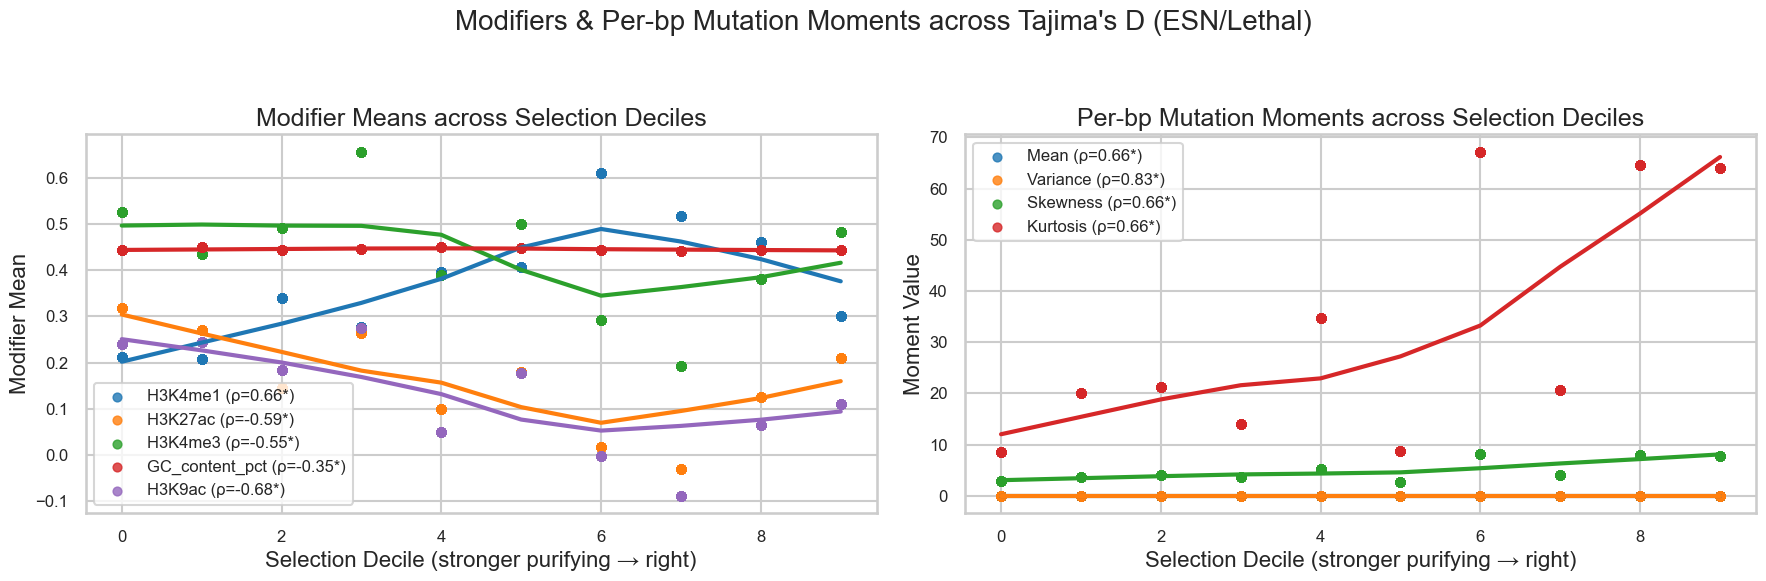


Spearman correlations: selection decile vs modifier means
  H3K4me1     : rho=0.660  p=3.11e-91
  H3K27ac     : rho=-0.588  p=3.75e-68
  H3K4me3     : rho=-0.552  p=1.79e-58
  GC_content_pct: rho=-0.345  p=1.44e-21
  H3K9ac      : rho=-0.684  p=2.35e-100

Spearman correlations: selection decile vs per-bp mutation moments
  Mean    : rho=0.661  p=2.52e-91
  Variance: rho=0.830  p=4.04e-184
  Skewness: rho=0.662  p=5.64e-92
  Kurtosis: rho=0.662  p=1.07e-91


In [ ]:
# --- Load & filter ---------------------------------------------------------
data_path = Path.home() / "Documents/GitHub/Random_Modifier/data/gene_level_data.csv"
df = pd.read_csv(data_path)

# Restrict to essential/lethal genes
df = df[(df["essentiality"] == "ESN") | (df["lethal"] == True)].copy()

# Predictors/modifiers to track across selection deciles
modifiers = ["H3K4me1", "H3K27ac", "H3K4me3", "GC_content_pct", "H3K9ac"]

# Required columns (now using per-bp rate, so need CDS length)
req_cols = modifiers + ["Mutations", "CDS length", "TajimasD"]
df = df.dropna(subset=req_cols).copy()

# --- Outcome: per-bp mutation rate ----------------------------------------
eps = 1e-9
df["mut_rate_per_bp"] = df["Mutations"] / (df["CDS length"] + eps)

# --- Selection deciles (stronger selection = more negative Tajima's D) ----
# Use qcut on -TajimasD so higher decile = stronger purifying selection
df["Sel_decile"] = pd.qcut(
    -df["TajimasD"], q=10, labels=False, duplicates="drop"
)

# Safety: ensure integer type and sorted uniqueness
df["Sel_decile"] = df["Sel_decile"].astype("Int64")
# Safety: ensure integer type and sorted uniqueness
df["Sel_decile"] = df["Sel_decile"].astype("Int64")

# Convert to numpy array, drop NaNs, and sort
valid_deciles = np.sort(df["Sel_decile"].dropna().to_numpy())


# --- Summarize by selection decile ----------------------------------------
rows = []
for sel in valid_deciles:
    sub = df[df["Sel_decile"] == sel]
    entry = {"Sel_decile": int(sel)}
    # Mean of modifiers in this decile
    for mod in modifiers:
        entry[f"{mod}_mean"] = float(sub[mod].mean())
    # Moments of per-bp mutation rate in this decile
    vals = sub["mut_rate_per_bp"].dropna().values
    if vals.size == 0:
        entry["Mutations_mean"] = np.nan
        entry["Mutations_var"]  = np.nan
        entry["Mutations_skew"] = np.nan
        entry["Mutations_kurt"] = np.nan
    else:
        entry["Mutations_mean"] = float(np.mean(vals))
        entry["Mutations_var"]  = float(np.var(vals, ddof=1)) if vals.size > 1 else 0.0
        entry["Mutations_skew"] = float(skew(vals, bias=False)) if vals.size >= 3 else np.nan
        entry["Mutations_kurt"] = float(kurtosis(vals, bias=False)) if vals.size >= 4 else np.nan
    rows.append(entry)

summary_df = pd.DataFrame(rows).sort_values("Sel_decile").reset_index(drop=True)

# --- Spearman correlations (selection decile vs. modifier means / moments) -
# We correlate across deciles (typically up to 10 points), so treat results as descriptive.
mod_corrs = {}
for mod in modifiers:
    rho, p = spearmanr(summary_df["Sel_decile"], summary_df[f"{mod}_mean"])
    mod_corrs[mod] = (rho, p)

mom_cols = {
    "Mean":     "Mutations_mean",
    "Variance": "Mutations_var",
    "Skewness": "Mutations_skew",
    "Kurtosis": "Mutations_kurt"
}
mut_corrs = {}
for name, col in mom_cols.items():
    rho, p = spearmanr(summary_df["Sel_decile"], summary_df[col])
    mut_corrs[name] = (rho, p)

# --- Plotting --------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
FIG_DIR  = Path.cwd() / "Figures"
FIG_DIR.mkdir(exist_ok=True, parents=True)
FIG_PATH = FIG_DIR / "af3_tajimas_trends.png"

mod_pal = sns.color_palette("tab10", n_colors=len(modifiers))
mom_pal = sns.color_palette("tab10", n_colors=len(mom_cols))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

# 1) Modifier trends across selection deciles
for i, mod in enumerate(modifiers):
    rho, p = mod_corrs[mod]
    star   = "*" if (p is not None and p < 0.05) else ""
    label  = f"{mod} (ρ={rho:.2f}{star})"
    # Draw LOWESS/LOESS-style smooth line and overlay decile points
    sns.regplot(
        x=summary_df["Sel_decile"],
        y=summary_df[f"{mod}_mean"],
        ax=axes[0],
        lowess=True,
        scatter=True,
        line_kws={"lw": 3 if (p is not None and p < 0.05) else 1.5},
        scatter_kws={"s": 40, "alpha": 0.8},
        color=mod_pal[i],
        label=label
    )
axes[0].set_title("Modifier Means across Selection Deciles", fontsize=18)
axes[0].set_xlabel("Selection Decile (stronger purifying → right)", fontsize=16)
axes[0].set_ylabel("Modifier Mean", fontsize=16)
axes[0].legend(fontsize=12, frameon=True)
axes[0].tick_params(labelsize=12)

# 2) Mutation-moment trends across selection deciles
for i, (name, col) in enumerate(mom_cols.items()):
    rho, p = mut_corrs[name]
    star   = "*" if (p is not None and p < 0.05) else ""
    label  = f"{name} (ρ={rho:.2f}{star})"
    sns.regplot(
        x=summary_df["Sel_decile"],
        y=summary_df[col],
        ax=axes[1],
        lowess=True,
        scatter=True,
        line_kws={"lw": 3 if (p is not None and p < 0.05) else 1.5},
        scatter_kws={"s": 40, "alpha": 0.8},
        color=mom_pal[i],
        label=label
    )
axes[1].set_title("Per-bp Mutation Moments across Selection Deciles", fontsize=18)
axes[1].set_xlabel("Selection Decile (stronger purifying → right)", fontsize=16)
axes[1].set_ylabel("Moment Value", fontsize=16)
axes[1].legend(fontsize=12, frameon=True)
axes[1].tick_params(labelsize=12)

plt.suptitle("Modifiers & Per-bp Mutation Moments across Tajima's D (ESN/Lethal)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# --- Save & show -----------------------------------------------------------
plt.savefig(FIG_PATH, dpi=300)
plt.show()

# --- (Optional) print correlations for the record -------------------------
print("\nSpearman correlations: selection decile vs modifier means")
for mod, (rho, p) in mod_corrs.items():
    print(f"  {mod:12s}: rho={rho:.3f}  p={p:.3g}")

print("\nSpearman correlations: selection decile vs per-bp mutation moments")
for name, (rho, p) in mut_corrs.items():
    print(f"  {name:8s}: rho={rho:.3f}  p={p:.3g}")
